<a href="https://colab.research.google.com/github/luciacubero20/Practicas_Redes_Neuronales_LuciaCubero/blob/main/Practica_04_Luc%C3%ADaCubero.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<font color="darkorange" size="10"><b>04. Clasificación con MLP</b></font>

Lucía Cubero Alonso

Correo institucional: lucicube@ucm.es


## 01. Ejercicio 1

In [ ]:
%reset -f

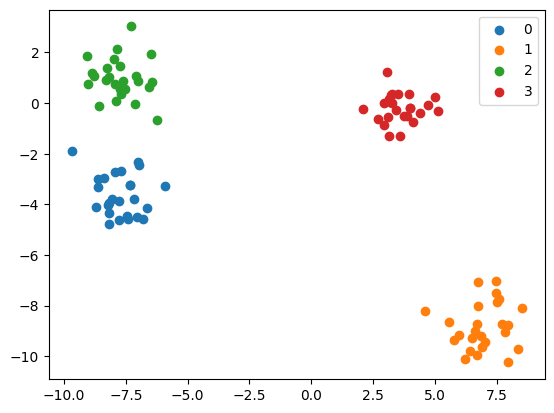

In [ ]:
from sklearn.datasets import make_blobs
from matplotlib import pyplot as plt
import matplotlib.pyplot as plt
import torch
from torch.utils.data import TensorDataset, DataLoader

X, y = make_blobs(centers=4, cluster_std=0.8)
plt.scatter(X[y == 0, 0], X[y == 0, 1], label="0")
plt.scatter(X[y == 1, 0], X[y == 1, 1], label="1")
plt.scatter(X[y == 2, 0], X[y == 2, 1], label="2")
plt.scatter(X[y == 3, 0], X[y == 3, 1], label="3")
plt.legend()


In [ ]:
x_mean, x_std = X.mean(), X.std()
X_norm = (X - x_mean) / x_std

tensor_X = torch.Tensor(X_norm)
tensor_y = torch.tensor(y, dtype=torch.long)

my_dataset = TensorDataset(tensor_X, tensor_y)
my_dataloader = DataLoader(my_dataset, batch_size=16, shuffle=True)


In [ ]:
class MLP(torch.nn.Module):
    def __init__(self, num_features):
        super().__init__()

        self.all_layers = torch.nn.Sequential(
            # 1st hidden layer
            torch.nn.Linear(num_features, 50),
            torch.nn.ReLU(),

            # 2nd hidden layer
            torch.nn.Linear(50, 25),
            torch.nn.ReLU(),

            # output layer

            torch.nn.Linear(25, 4)
        )

    def forward(self, x):
        output = self.all_layers(x)

        return output

In [ ]:
!pip install torcheval

In [ ]:
from torcheval.metrics import MulticlassAccuracy, MulticlassConfusionMatrix

torch.manual_seed(1)

model = MLP(num_features=2)

loss_fn = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

acc = MulticlassAccuracy(num_classes=4)
m_confusion = MulticlassConfusionMatrix(num_classes=4)

In [ ]:
num_epochs = 100
loss_list, acc_list = [], []

for epoch in range(num_epochs):
    model.train()
    for batch_idx, (features, targets) in enumerate(my_dataloader):

        # forward
        output = model(features)
        loss = loss_fn(output, targets)

        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        acc.update(output, targets)

        loss_list.append(loss.item())
        acc_list.append(acc.compute().item())

        if not batch_idx % 100:
            print(
                f"Epoch: {epoch+1:03d}/{num_epochs:03d}"
                f" | Batch {batch_idx:03d}/{len(my_dataloader):03d}"
                f" | Train Loss: {loss:.2f}"
                f" | Accuracy: {acc.compute():.2f}"
            )

Epoch: 001/100 | Batch 000/007 | Train Loss: 1.47 | Accuracy: 0.06
Epoch: 002/100 | Batch 000/007 | Train Loss: 1.33 | Accuracy: 0.24
Epoch: 003/100 | Batch 000/007 | Train Loss: 1.32 | Accuracy: 0.28
Epoch: 004/100 | Batch 000/007 | Train Loss: 1.24 | Accuracy: 0.43
Epoch: 005/100 | Batch 000/007 | Train Loss: 1.26 | Accuracy: 0.50
Epoch: 006/100 | Batch 000/007 | Train Loss: 1.09 | Accuracy: 0.56
Epoch: 007/100 | Batch 000/007 | Train Loss: 1.06 | Accuracy: 0.59
Epoch: 008/100 | Batch 000/007 | Train Loss: 0.96 | Accuracy: 0.61
Epoch: 009/100 | Batch 000/007 | Train Loss: 0.91 | Accuracy: 0.64
Epoch: 010/100 | Batch 000/007 | Train Loss: 0.82 | Accuracy: 0.66
Epoch: 011/100 | Batch 000/007 | Train Loss: 0.74 | Accuracy: 0.69
Epoch: 012/100 | Batch 000/007 | Train Loss: 0.83 | Accuracy: 0.71
Epoch: 013/100 | Batch 000/007 | Train Loss: 0.55 | Accuracy: 0.73
Epoch: 014/100 | Batch 000/007 | Train Loss: 0.54 | Accuracy: 0.74
Epoch: 015/100 | Batch 000/007 | Train Loss: 0.54 | Accuracy: 

In [ ]:
model.eval()
yp = model(tensor_X)
yp

tensor([[-2.0777e-01, -5.2287e+00,  3.1699e+00, -3.7835e+00],
        [ 6.6344e+00, -3.0367e+00, -2.4118e+00, -4.1523e+00],
        [ 3.6973e+00, -4.5175e+00,  1.0355e+00, -4.8841e+00],
        [-9.1477e-01,  4.9995e+00, -6.4107e+00, -1.6691e+00],
        [-3.0068e+00, -5.7944e+00,  4.4101e+00, -3.0255e+00],
        [-3.6458e+00, -6.0958e+00,  4.7112e+00, -3.1067e+00],
        [-2.8477e+00,  5.0855e+00, -6.6102e+00, -6.3943e-01],
        [-4.6222e+00, -6.2997e+00,  4.8441e+00, -2.7986e+00],
        [-2.7004e+00, -5.2545e+00,  3.7169e+00, -2.2570e+00],
        [-5.3011e+00, -2.4752e+00, -1.5356e+00,  4.8363e+00],
        [ 6.4590e+00, -2.7767e+00, -2.6043e+00, -3.9617e+00],
        [-2.2646e+00, -5.8806e+00,  4.5321e+00, -3.5540e+00],
        [ 5.1904e+00, -3.1897e+00, -1.1278e+00, -3.8426e+00],
        [-2.7546e+00,  4.6463e+00, -6.2039e+00, -4.4895e-01],
        [-2.2612e+00,  6.7900e+00, -7.9067e+00, -1.8636e+00],
        [-5.2821e+00, -2.1156e+00, -1.7607e+00,  4.7184e+00],
        

In [ ]:
m_confusion.update(yp, tensor_y)
print(m_confusion.compute())

tensor([[25.,  0.,  0.,  0.],
        [ 0., 25.,  0.,  0.],
        [ 0.,  0., 25.,  0.],
        [ 0.,  0.,  0., 25.]])


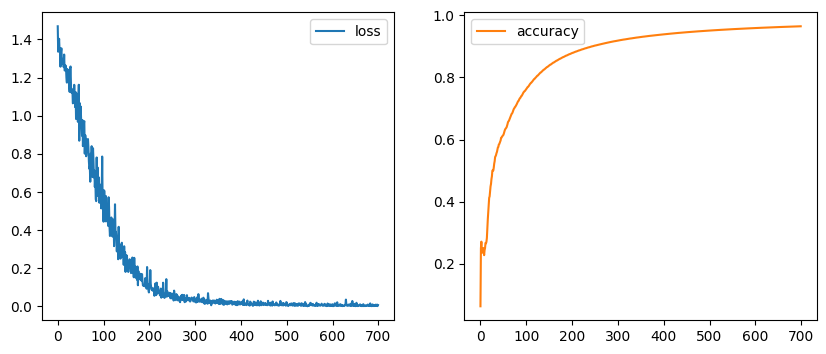

In [ ]:

plt.figure(figsize=(10, 4))


plt.subplot(1, 2, 1)
plt.plot(loss_list)
plt.legend(['loss'])


plt.subplot(1, 2, 2)
plt.plot(acc_list, color='tab:orange')
plt.legend(['accuracy'])


plt.show()



## 02. Ejercicio 2

In [ ]:
%reset -f

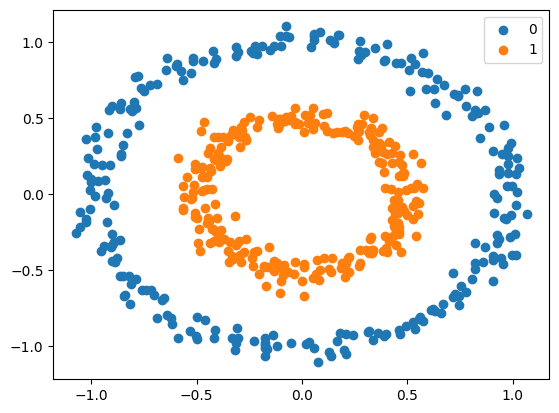

In [ ]:
from sklearn.datasets import make_circles
from matplotlib import pyplot as plt

X, y = make_circles(n_samples=500, noise=0.05, factor=0.5)

plt.scatter(X[y == 0, 0], X[y == 0, 1], label="0")
plt.scatter(X[y == 1, 0], X[y == 1, 1], label="1")
plt.legend()

In [ ]:
!pip install torcheval

In [ ]:
# Preparamos los datos como antes, pero y no hay que normalizarla
import torch
from torch.utils.data import TensorDataset, DataLoader

# Normalizamos solo X

x_mean, x_std = X.mean(), X.std()
X_norm = (X - x_mean) / x_std

tensor_X = torch.Tensor(X_norm)
tensor_y = torch.Tensor(y)

my_dataset = TensorDataset(tensor_X,tensor_y) # create your datset
my_dataloader = DataLoader(my_dataset, batch_size=16, shuffle=True) # create your dataloader

In [ ]:
# definimos mi red igual que antes
# Es una red con 3 capas (50,25,1), todo relu menos la ultima capa que hace
# la clasificación binaria con una sigmoide

class MLP(torch.nn.Module):
    def __init__(self, num_features):
        super().__init__()

        self.all_layers = torch.nn.Sequential(

            # 1st hidden layer
            torch.nn.Linear(num_features, 50),
            torch.nn.ReLU(),

            # 2nd hidden layer
            torch.nn.Linear(50, 25),
            torch.nn.ReLU(),

            # output layer
            torch.nn.Linear(25, 1),
            # torch.nn.Sigmoid() # ver comentario 1

        )

    def forward(self, x):
        output = self.all_layers(x)
        # return output
        return output.flatten() # ver comentario 2

In [ ]:
from torcheval.metrics import BinaryAccuracy, BinaryConfusionMatrix

# definimos hiper-parámetros

torch.manual_seed(1)

model = MLP(num_features=2) # instanciamos el modelo

# loss_fn = torch.nn.BCELoss() # Ojo, ahora es BCE, necesita sigmoid
loss_fn = torch.nn.BCEWithLogitsLoss() # Ojo, ahora es BCELog, no necesita sigmoid

optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # usamos Adam

acc = BinaryAccuracy() # calculamos la precisión (accurary)
m_confusion = BinaryConfusionMatrix(threshold=0.5)

In [ ]:
num_epochs = 100

# vamos a guardar el lost pero tambien el accuracy
loss_list, acc_list = [], []

for epoch in range(num_epochs):

    model.train()
    for batch_idx, (features, targets) in enumerate(my_dataloader):

        # forward
        output = model(features)
        loss = loss_fn(output, targets)

        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Esto es algo especifico para la evaluacion, en cada epoca actualizamos:
        acc.update(output, targets)      # el accuracy

        # añadimos los nuevos valores a la lista
        loss_list.append(loss.item())
        acc_list.append(acc.compute().item())

        if not batch_idx % 100:
            ### Imprimimos info
            print(
                f"Epoch: {epoch+1:03d}/{num_epochs:03d}"
                f" | Batch {batch_idx:03d}/{len(my_dataloader):03d}"
                f" | Train Loss: {loss:.2f}"
                f" | Accuracy: {acc.compute():.2f}"
            )

Epoch: 001/100 | Batch 000/032 | Train Loss: 0.69 | Accuracy: 0.44
Epoch: 002/100 | Batch 000/032 | Train Loss: 0.64 | Accuracy: 0.50
Epoch: 003/100 | Batch 000/032 | Train Loss: 0.59 | Accuracy: 0.50
Epoch: 004/100 | Batch 000/032 | Train Loss: 0.51 | Accuracy: 0.50
Epoch: 005/100 | Batch 000/032 | Train Loss: 0.43 | Accuracy: 0.52
Epoch: 006/100 | Batch 000/032 | Train Loss: 0.35 | Accuracy: 0.60
Epoch: 007/100 | Batch 000/032 | Train Loss: 0.28 | Accuracy: 0.66
Epoch: 008/100 | Batch 000/032 | Train Loss: 0.16 | Accuracy: 0.71
Epoch: 009/100 | Batch 000/032 | Train Loss: 0.12 | Accuracy: 0.74
Epoch: 010/100 | Batch 000/032 | Train Loss: 0.08 | Accuracy: 0.77
Epoch: 011/100 | Batch 000/032 | Train Loss: 0.07 | Accuracy: 0.80
Epoch: 012/100 | Batch 000/032 | Train Loss: 0.06 | Accuracy: 0.81
Epoch: 013/100 | Batch 000/032 | Train Loss: 0.03 | Accuracy: 0.83
Epoch: 014/100 | Batch 000/032 | Train Loss: 0.05 | Accuracy: 0.84
Epoch: 015/100 | Batch 000/032 | Train Loss: 0.02 | Accuracy: 

In [ ]:
# Vemos que predicciones hace nuestro modelo para nuestro X

model.eval()
yp = model(tensor_X)
yp

tensor([-11.1629, -12.3890, -12.7009, -10.4986,  -7.9937,   9.1068,   8.9688,
          7.5379, -10.0526,  10.7962,  12.3721,   8.9346, -10.7780,  -8.7776,
          8.7660,  11.0237,  -7.9160,  -8.8234, -11.9144,  11.0134,   6.9282,
         11.7747,  10.4069,  10.9080,  10.6648, -11.9350,   9.1321,   8.6619,
        -11.8637,   9.3854,  -7.5345,  -9.7604,  -9.2380, -12.0035,  11.7183,
         10.0766, -11.4335,  11.0219,   8.9934, -10.3870,   8.2786, -10.7421,
        -10.2862,   9.9343,  11.0124,   7.3757,   9.3678,  -8.6479,   8.7691,
         10.5966,   9.4372,  10.2827, -10.5016,  -6.2622,  11.4937,  -7.7977,
         -7.7975, -11.5875,  -8.8042,  -9.8608, -11.9410,  -8.4410,   8.9779,
         -8.6586, -10.9429,  11.7243,   9.3752, -10.9697,   8.3828,  -8.7458,
         11.6581,  -9.3970,  11.9951,  -9.6886,   5.1299,  -9.5364,  -9.3171,
         11.3003,   8.2972,  10.3942,  -8.3777,  10.4719, -12.4270, -11.0217,
          4.9758, -10.7508, -10.1113,   9.6501,  -7.9504,   8.35

In [ ]:
# Calculamos una matriz de confusion

k = BinaryConfusionMatrix(threshold=0.)
k.update(yp, tensor_y.long())
print(k.compute())

tensor([[250.,   0.],
        [  0., 250.]])


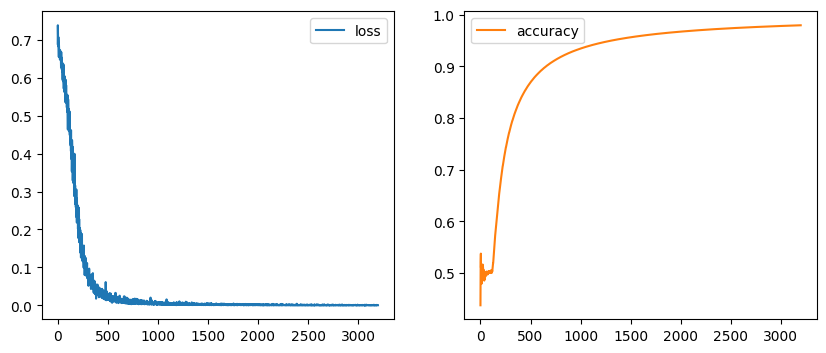

In [ ]:

plt.figure(figsize=(10, 4))


plt.subplot(1, 2, 1)
plt.plot(loss_list)
plt.legend(['loss'])


plt.subplot(1, 2, 2)
plt.plot(acc_list, color='tab:orange')
plt.legend(['accuracy'])


plt.show()

## 03. Ejercicio 3

In [ ]:
%reset -f

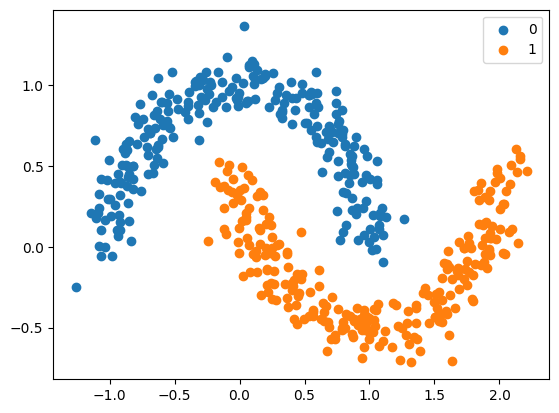

In [ ]:
from sklearn.datasets import make_moons
from matplotlib import pyplot as plt

X, y = make_moons(n_samples=500, noise=0.1)

plt.scatter(X[y == 0, 0], X[y == 0, 1], label="0")
plt.scatter(X[y == 1, 0], X[y == 1, 1], label="1")
plt.legend()

In [ ]:
!pip install torcheval

In [ ]:
# Preparamos los datos como antes, pero y no hay que normalizarla
import torch
from torch.utils.data import TensorDataset, DataLoader

# Normalizamos solo X

x_mean, x_std = X.mean(), X.std()
X_norm = (X - x_mean) / x_std

tensor_X = torch.Tensor(X_norm)
tensor_y = torch.Tensor(y)

my_dataset = TensorDataset(tensor_X,tensor_y) # create your datset
my_dataloader = DataLoader(my_dataset, batch_size=16, shuffle=True) # create your dataloader

In [ ]:
# definimos mi red igual que antes
# Es una red con 3 capas (50,25,1), todo relu menos la ultima capa que hace
# la clasificación binaria con una sigmoide

class MLP(torch.nn.Module):
    def __init__(self, num_features):
        super().__init__()

        self.all_layers = torch.nn.Sequential(

            # 1st hidden layer
            torch.nn.Linear(num_features, 50),
            torch.nn.ReLU(),

            # 2nd hidden layer
            torch.nn.Linear(50, 25),
            torch.nn.ReLU(),

            # output layer
            torch.nn.Linear(25, 1),
            # torch.nn.Sigmoid() # ver comentario 1

        )

    def forward(self, x):
        output = self.all_layers(x)
        # return output
        return output.flatten() # ver comentario 2

In [ ]:
from torcheval.metrics import BinaryAccuracy, BinaryConfusionMatrix

# definimos hiper-parámetros

torch.manual_seed(1)

model = MLP(num_features=2) # instanciamos el modelo

# loss_fn = torch.nn.BCELoss() # Ojo, ahora es BCE, necesita sigmoid
loss_fn = torch.nn.BCEWithLogitsLoss() # Ojo, ahora es BCELog, no necesita sigmoid

optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # usamos Adam

acc = BinaryAccuracy() # calculamos la precisión (accurary)
m_confusion = BinaryConfusionMatrix(threshold=0.5)

In [ ]:
num_epochs = 100

# vamos a guardar el lost pero tambien el accuracy
loss_list, acc_list = [], []

for epoch in range(num_epochs):

    model.train()
    for batch_idx, (features, targets) in enumerate(my_dataloader):

        # forward
        output = model(features)
        loss = loss_fn(output, targets)

        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Esto es algo especifico para la evaluacion, en cada epoca actualizamos:
        acc.update(output, targets)      # el accuracy

        # añadimos los nuevos valores a la lista
        loss_list.append(loss.item())
        acc_list.append(acc.compute().item())

        if not batch_idx % 100:
            ### Imprimimos info
            print(
                f"Epoch: {epoch+1:03d}/{num_epochs:03d}"
                f" | Batch {batch_idx:03d}/{len(my_dataloader):03d}"
                f" | Train Loss: {loss:.2f}"
                f" | Accuracy: {acc.compute():.2f}"
            )

Epoch: 001/100 | Batch 000/032 | Train Loss: 0.75 | Accuracy: 0.69
Epoch: 002/100 | Batch 000/032 | Train Loss: 0.57 | Accuracy: 0.67
Epoch: 003/100 | Batch 000/032 | Train Loss: 0.66 | Accuracy: 0.74
Epoch: 004/100 | Batch 000/032 | Train Loss: 0.28 | Accuracy: 0.78
Epoch: 005/100 | Batch 000/032 | Train Loss: 0.28 | Accuracy: 0.80
Epoch: 006/100 | Batch 000/032 | Train Loss: 0.29 | Accuracy: 0.82
Epoch: 007/100 | Batch 000/032 | Train Loss: 0.28 | Accuracy: 0.83
Epoch: 008/100 | Batch 000/032 | Train Loss: 0.19 | Accuracy: 0.85
Epoch: 009/100 | Batch 000/032 | Train Loss: 0.20 | Accuracy: 0.86
Epoch: 010/100 | Batch 000/032 | Train Loss: 0.08 | Accuracy: 0.87
Epoch: 011/100 | Batch 000/032 | Train Loss: 0.10 | Accuracy: 0.87
Epoch: 012/100 | Batch 000/032 | Train Loss: 0.11 | Accuracy: 0.88
Epoch: 013/100 | Batch 000/032 | Train Loss: 0.07 | Accuracy: 0.89
Epoch: 014/100 | Batch 000/032 | Train Loss: 0.06 | Accuracy: 0.90
Epoch: 015/100 | Batch 000/032 | Train Loss: 0.05 | Accuracy: 

In [ ]:
# Vemos que predicciones hace nuestro modelo para nuestro X

model.eval()
yp = model(tensor_X)
yp

tensor([-14.6707,  13.2618,   8.8654,   9.1729,  13.9162,  11.3507,  15.3644,
         -8.2962, -11.6977,  10.9996, -13.4572,  12.0663,   4.7542, -14.3194,
         14.3789,  11.7606,  -9.0191,  13.7599,   5.0561, -17.1800,  13.4968,
        -13.8478, -17.0530,   8.0303, -12.3457,  -9.0190,   7.0537,  15.9630,
        -14.4398,   8.9353,   7.4403,  16.0355,  12.1257, -10.9064, -11.2498,
         -6.3036,  -8.0572,   7.9934, -17.6728,  10.8219, -15.0371,  14.0126,
        -17.5370, -12.8556,  -9.4636,  -7.2099,  12.4404,  15.7080, -16.9677,
         14.8091,  -9.5148,  12.7765,  11.4603,   8.3976,  -9.8747,  11.4780,
          6.5491,   8.9249, -10.6474,  12.4980,  -9.9560,   5.5386,  13.8857,
         16.3687, -18.4671,  -8.8851, -17.5639,  11.0162, -11.4348, -14.4458,
        -15.3547,  12.1505, -15.3457,   7.3251,   6.9165,   8.6382,  10.7880,
        -17.7446,  -9.2442,   3.4994,  10.3935,  -3.1000,  15.8081, -15.9006,
        -16.1526, -11.9498,  -8.6918,  16.6333, -15.9377, -10.69

In [ ]:
# Calculamos una matriz de confusion

k = BinaryConfusionMatrix(threshold=0.)
k.update(yp, tensor_y.long())
print(k.compute())

tensor([[250.,   0.],
        [  0., 250.]])


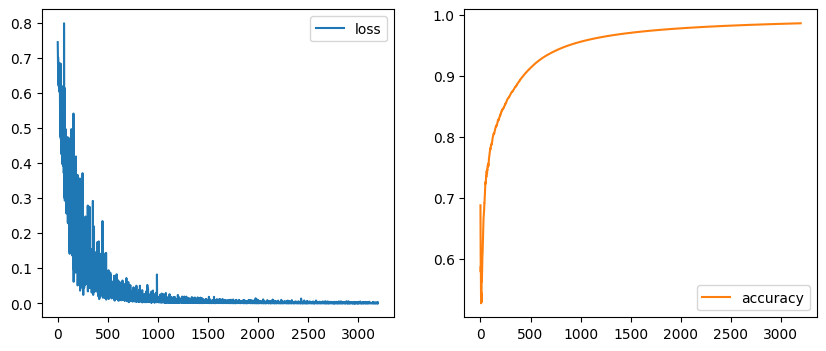

In [ ]:

plt.figure(figsize=(10, 4))


plt.subplot(1, 2, 1)
plt.plot(loss_list)
plt.legend(['loss'])


plt.subplot(1, 2, 2)
plt.plot(acc_list, color='tab:orange')
plt.legend(['accuracy'])


plt.show()

## 04. Ejercicio 4

In [ ]:
%reset -f

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt

url = 'https://raw.githubusercontent.com/mcstllns/UNIR2024/main/data-affairs.csv'
data  = pd.read_csv(url)
print(data.keys())
data.head()

Index(['affairs', 'gender', 'age', 'yearsmarried', 'children', 'religiousness',
       'education', 'occupation', 'rating'],
      dtype='object')


,affairs,gender,age,yearsmarried,children,religiousness,education,occupation,rating
0,0,0,37.0,10.00,0,3,18,7,4
1,0,1,27.0,4.00,0,4,14,6,4
2,0,1,32.0,15.00,1,1,12,1,4
3,0,0,57.0,15.00,1,5,18,6,5
4,0,0,22.0,0.75,0,2,17,6,3


In [ ]:
X = data.drop('affairs', axis=1)
y = data['affairs']
y = (y > 0).astype(int) #binarizar

print(X.shape)
print(y.shape)
print(y.unique())

(601, 8)
(601,)
[0 1]


In [ ]:
!pip install torcheval

In [ ]:
# Preparamos los datos como antes, pero y no hay que normalizarla
import torch
from torch.utils.data import TensorDataset, DataLoader
from torcheval.metrics import BinaryAccuracy, BinaryConfusionMatrix

# Normalizamos solo X

x_mean, x_std = X.mean(), X.std()
X_norm = (X - x_mean) / x_std

tensor_X = torch.tensor(X_norm.values, dtype=torch.float32)
tensor_y = torch.tensor(y.values, dtype=torch.float32)

my_dataset = TensorDataset(tensor_X,tensor_y) # create your datset
my_dataloader = DataLoader(my_dataset, batch_size=16, shuffle=True) # create your dataloader # create your dataloader

In [ ]:
class MLP(torch.nn.Module):
    def __init__(self, num_features):
        super().__init__()

        self.all_layers = torch.nn.Sequential(

            # 1st hidden layer
            torch.nn.Linear(num_features, 64),
            torch.nn.ReLU(),

            # 2nd hidden layer
            torch.nn.Linear(64, 32),
            torch.nn.ReLU(),

            # output layer
            torch.nn.Linear(32, 1),
            # torch.nn.Sigmoid() # ver comentario 1

        )

    def forward(self, x):
        output = self.all_layers(x)
        # return output
        return output.flatten() # ver comentario 2

In [ ]:
from torcheval.metrics import BinaryAccuracy, BinaryConfusionMatrix

# definimos hiper-parámetros

torch.manual_seed(1)

model = MLP(num_features=8) # instanciamos el modelo

# loss_fn = torch.nn.BCELoss() # Ojo, ahora es BCE, necesita sigmoid
num_ceros = (tensor_y == 0).sum()
num_unos  = (tensor_y == 1).sum()
peso = torch.tensor([num_ceros / num_unos], dtype=torch.float32)
loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=peso) # Ojo, ahora es BCELog, no necesita sigmoid

optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # usamos Adam

acc = BinaryAccuracy() # calculamos la precisión (accurary)
m_confusion = BinaryConfusionMatrix(threshold=0.5)

In [ ]:
# guardar el lost pero tambien el accuracy
num_epochs = 300
loss_list, acc_list = [], []        # por batch
loss_epoch_list = []                # por época

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    for batch_idx, (features, targets) in enumerate(my_dataloader):

        # forward
        output = model(features)
        loss   = loss_fn(output, targets)

        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        acc.update(output, targets)

        loss_list.append(loss.item())
        acc_list.append(acc.compute().item())
        epoch_loss += loss.item()

        if not batch_idx % 100:
            print(
                f"Epoch: {epoch+1:03d}/{num_epochs:03d}"
                f" | Batch {batch_idx:03d}/{len(my_dataloader):03d}"
                f" | Train Loss: {loss:.2f}"
                f" | Accuracy: {acc.compute():.2f}"
            )

    # fuera del bucle de batches
    loss_epoch_list.append(epoch_loss / len(my_dataloader))

Epoch: 001/300 | Batch 000/038 | Train Loss: 1.04 | Accuracy: 0.75
Epoch: 002/300 | Batch 000/038 | Train Loss: 0.99 | Accuracy: 0.75
Epoch: 003/300 | Batch 000/038 | Train Loss: 0.83 | Accuracy: 0.75
Epoch: 004/300 | Batch 000/038 | Train Loss: 0.80 | Accuracy: 0.75
Epoch: 005/300 | Batch 000/038 | Train Loss: 0.97 | Accuracy: 0.75
Epoch: 006/300 | Batch 000/038 | Train Loss: 1.18 | Accuracy: 0.75
Epoch: 007/300 | Batch 000/038 | Train Loss: 0.74 | Accuracy: 0.75
Epoch: 008/300 | Batch 000/038 | Train Loss: 0.65 | Accuracy: 0.75
Epoch: 009/300 | Batch 000/038 | Train Loss: 0.84 | Accuracy: 0.75
Epoch: 010/300 | Batch 000/038 | Train Loss: 1.32 | Accuracy: 0.75
Epoch: 011/300 | Batch 000/038 | Train Loss: 1.02 | Accuracy: 0.75
Epoch: 012/300 | Batch 000/038 | Train Loss: 0.82 | Accuracy: 0.75
Epoch: 013/300 | Batch 000/038 | Train Loss: 0.63 | Accuracy: 0.75
Epoch: 014/300 | Batch 000/038 | Train Loss: 0.88 | Accuracy: 0.75
Epoch: 015/300 | Batch 000/038 | Train Loss: 0.77 | Accuracy: 

In [ ]:
model.eval()
yp = model(tensor_X)


In [ ]:
k = BinaryConfusionMatrix(threshold=0.)
k.update(yp, tensor_y.long())
print(k.compute())

tensor([[441.,  10.],
        [  0., 150.]])


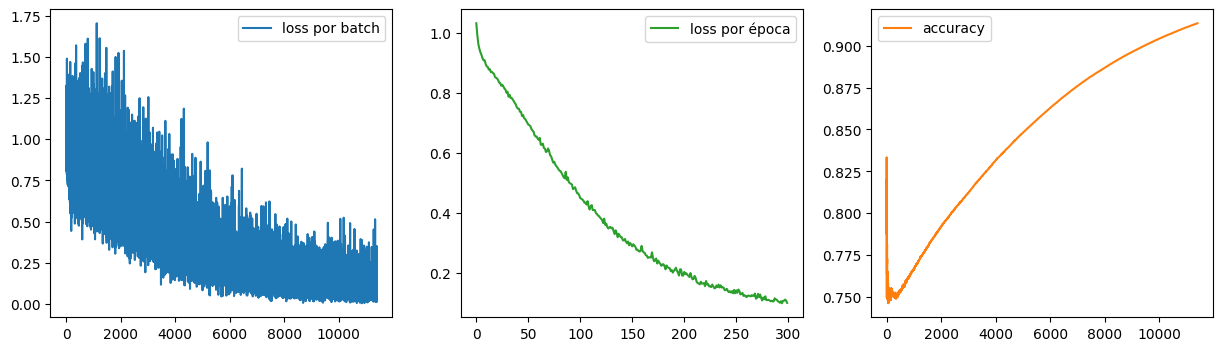

In [ ]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(loss_list)
plt.legend(['loss por batch'])

plt.subplot(1, 3, 2)
plt.plot(loss_epoch_list, color='tab:green')
plt.legend(['loss por época'])

plt.subplot(1, 3, 3)
plt.plot(acc_list, color='tab:orange')
plt.legend(['accuracy'])

plt.show()

In [ ]:
print(f"Accuracy del modelo MLP: {acc_list[-1]:.4f}")

Accuracy del modelo MLP: 0.9135
